In [1]:
import pandas as pd

df = pd.read_csv('student_data.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("talk")  # makes text bigger
plt.rcParams['figure.figsize'] = (8,5)

## Exploratory Data Analysis - Questions

1. How are final grades distributed among students?
2. Does study time affect student performance?
3. How do absences impact final grades?
4. Is there any difference in performance based on gender?
5. What relationships exist between numerical variables?


In [11]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


Dataset contains student performance data with both numerical and categorical variables. No missing values are present.

/tmp/ipykernel_804/727351834.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='G3', data=df, palette='Set2')


<Axes: xlabel='sex', ylabel='G3'>

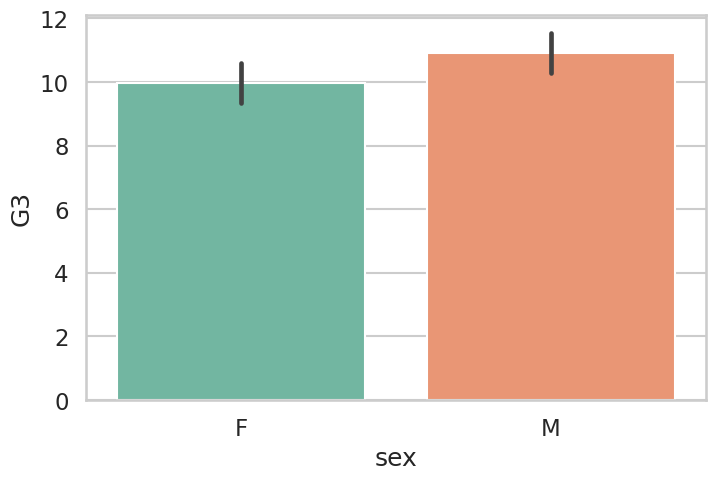

In [4]:
sns.barplot(x='sex', y='G3', data=df, palette='Set2')


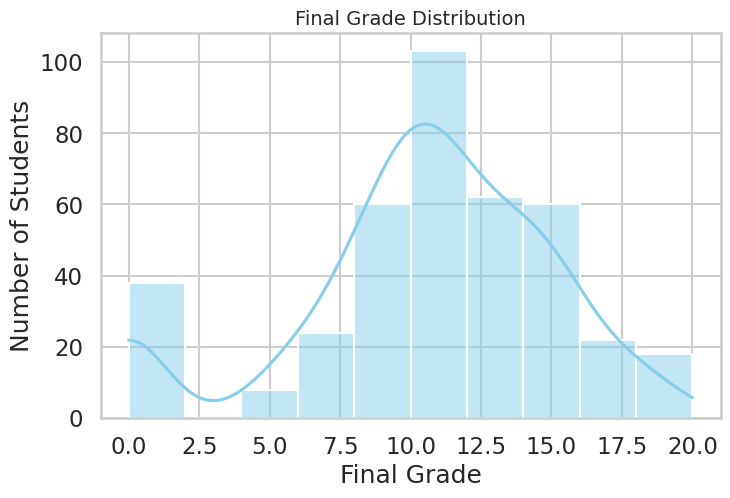

In [5]:
sns.histplot(df['G3'], bins=10, kde=True, color='skyblue')
plt.title("Final Grade Distribution", fontsize=14)
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.show()

Observation: Most students score in the mid-range, with fewer extreme scores.

/tmp/ipykernel_804/866031110.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='studytime', y='G3', data=df, palette='pastel')


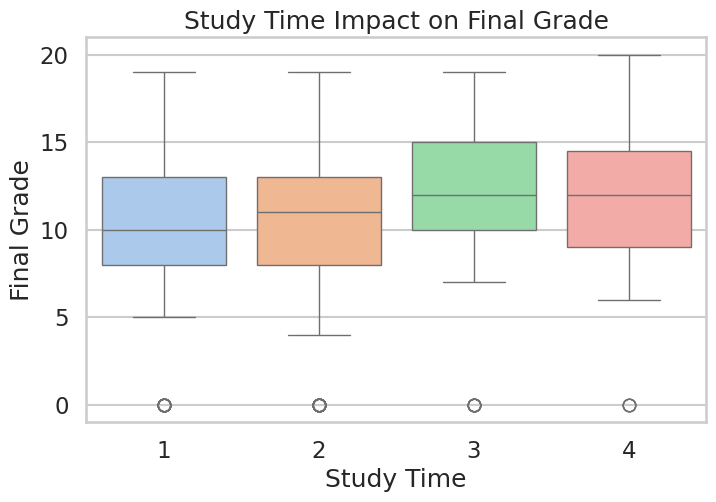

In [6]:
sns.boxplot(x='studytime', y='G3', data=df, palette='pastel')
plt.title("Study Time Impact on Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.show()

Observation: Higher study time leads to better performance.

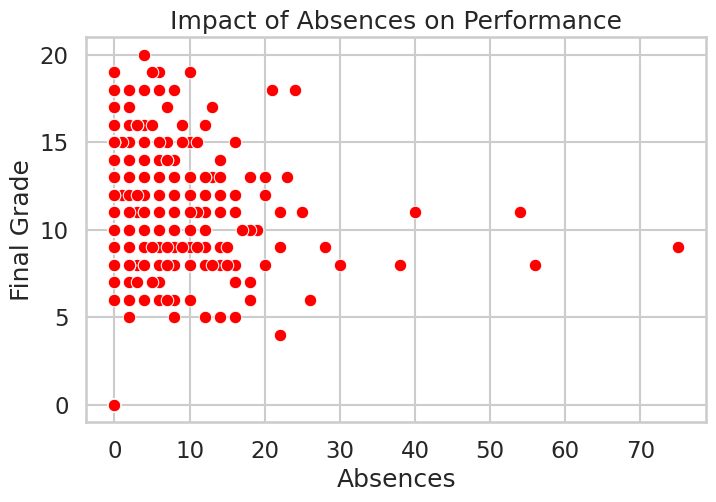

In [7]:
sns.scatterplot(x='absences', y='G3', data=df, color='red')
plt.title("Impact of Absences on Performance")
plt.xlabel("Absences")
plt.ylabel("Final Grade")
plt.show()

Observation: Students with more absences tend to have lower grades.

/tmp/ipykernel_804/2221827677.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='G3', data=df, palette='Set1')


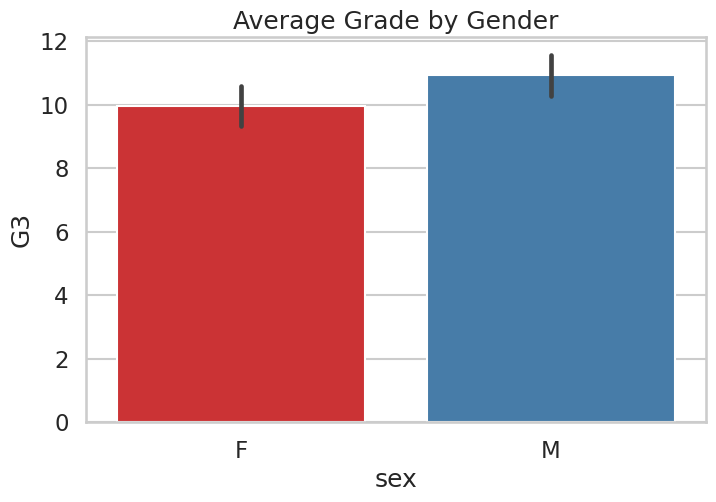

In [8]:
sns.barplot(x='sex', y='G3', data=df, palette='Set1')
plt.title("Average Grade by Gender")
plt.show()

Observation: There is a slight variation in performance between genders.

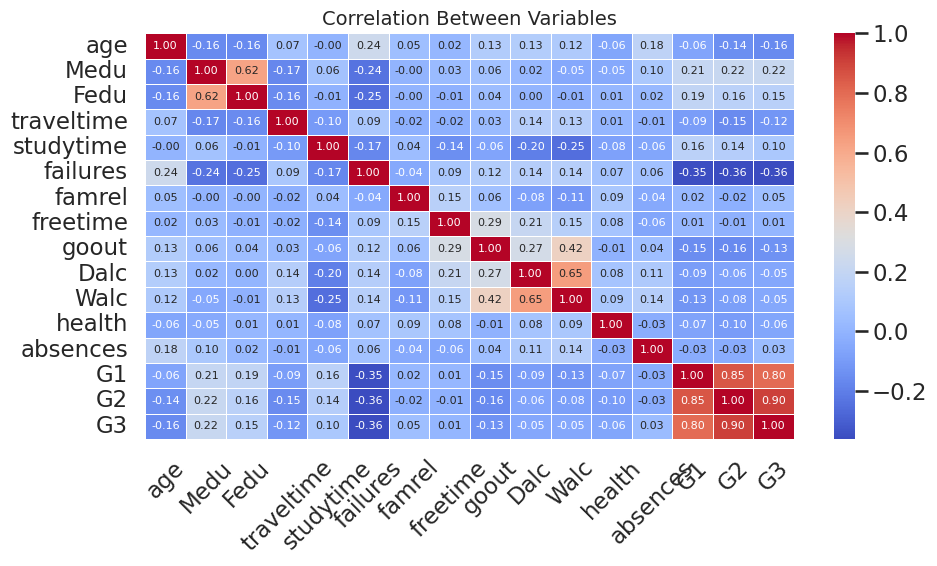

In [10]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))  # bigger size

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",          # only 2 decimal points
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size":8}   # smaller text
)

plt.title("Correlation Between Variables", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

Observation: G1, G2, and G3 are strongly correlated. Absences negatively affect performance.

## Hypothesis Testing

Hypothesis: Increased study time improves student performance.

Result: The boxplot shows that students who study more tend to have higher final grades.

Conclusion: The hypothesis is supported by the data.


## Data Storytelling

The analysis shows that student performance is strongly influenced by study habits and attendance. Students who dedicate more time to studying tend to achieve higher grades, while frequent absences negatively impact performance.

The strong correlation between G1, G2, and G3 indicates consistent academic behavior across evaluations. These insights highlight the importance of regular study and attendance in improving academic outcomes.


## Conclusion

This project analyzed student performance using data visualization techniques. Key factors affecting performance include study time and attendance. The dataset revealed clear patterns that can help improve student outcomes through better study habits and reduced absenteeism.

The visualizations were designed to clearly communicate insights and support data-driven decision-making.
